In [1]:
import numpy as np
import matplotlib.pyplot as plt

class SimplePDE:
  """
  Solve simple diffusion problem on [0,1] using P1 finite elements.
  """

  def __init__(self, N):
    self.N = N

  def matrix(self, coeff):
    """
    Assemble components of matrix.
    """

    if len(coeff) != 3:
      raise Exception(f"Wrong number of matrix components ({len(coeff)} != 3).")

    # diffusion component
    [nx, I] = np.shape(coeff[0])
    a = coeff[0][:,:]
    A0 = []
    for i in range(I):        
      # assemble A, a piecewise constant on grid
      # linearly dependent on a
      Ai = np.zeros((self.N+1,self.N+1))
      Ai.flat[self.N+2::self.N+2] = (a[1:,i] + a[:-1, i]) * self.N # set diag
      Ai.flat[1::self.N+2] = -a[:,i] * self.N # set first upper diag
      Ai.flat[self.N+1::self.N+2] = -a[:,i] * self.N # set first lower diag
      Ai[[0,-1]] = 0 # for dirichlet boundary
      A0.append(Ai)

    # convection component
    [nx, I] = np.shape(coeff[1])
    v = coeff[1][0,:]
    # v= np.zeros_like(v)
    A1 = []
    for i in range(I):
      # linearly dependent on v
      Ai = np.zeros((self.N+1,self.N+1))
      Ai.flat[1::self.N+2] = v[i]# set first upper diag
      Ai.flat[self.N+1::self.N+2] = -v[i] # set first lower diag
      Ai[[0,-1]] = 0 # for dirichlet boundary
      A1.append(Ai)

    # constant part (from boundary)
    [nx, I] = np.shape(coeff[2])
    A2 = []
    for i in range(I):
      # constant part of matrix
      Ai = np.zeros((self.N+1,self.N+1))
      Ai[0,0] = 1
      Ai[-1,-1] = 1
      A2.append(Ai)

    return [A0, A1, A2]
  
  def rhs(self, coeff):
    """
    Assemble components of rhs.
    """

    if len(coeff) != 1:
      raise Exception(f"Wrong number of rhs components ({len(coeff)} != 1).")
    
    [nx, I] = np.shape(coeff[0])
    
    # constant rhs
    F0 = []
    for i in range(I):
      # constant part of rhs
      Fi = np.full((self.N+1,1), 10/(self.N)) # assume RHS = 1 
      Fi[[0,-1]] = 0 # boundary condition
      F0.append(Fi)

    return [F0]

  def solve(self, coeff):
    """
    Assemble and solve FE problem for coeff.
    """
    I = np.shape(coeff[0][0])[1]
    
    U = []

    for i in range(I):
      A = self.matrix([coeff[0][k][:,i, np.newaxis] for k in range(len(coeff[0]))])
      b = self.rhs([coeff[1][k][:,i, np.newaxis] for k in range(len(coeff[1]))])
      U.append(np.linalg.solve(A[0][0] + A[1][0] + A[2][0], b[0][0]).reshape((-1,1)))
    
    return U

class diffusion_coeff:

  def __init__(self, Nx, Ny, offset, var):
    self.Nx = Nx
    self.Ny = Ny
    self.offset = offset
    self.var = var

  def __call__(self, X):
    c = np.full(len(X), self.offset,dtype=float)
    for i, x in enumerate(X):
      k = np.arange(1,len(x)-1)
      c[i] += np.sum(np.exp(-k) * np.sin(np.pi*k*x[0]/(self.Nx-1)) \
                      * (x[k+1]/(self.Ny-1) - 0.5) * self.var)
    return c

### PDE test

Solve the PDE using P1 finite elements for a random parameter

(200, 7)


Text(0, 0.5, 'A')

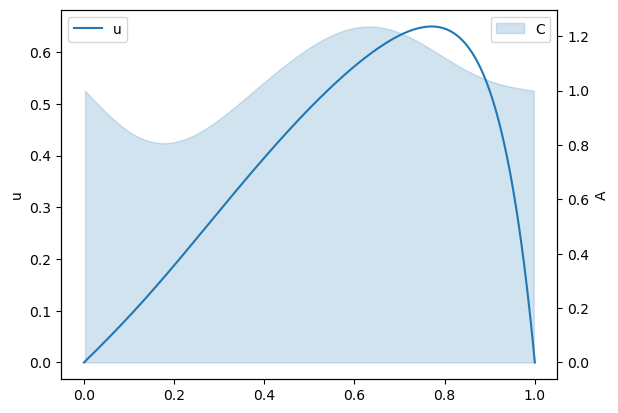

In [2]:
Nx = 200    # spatial resolution
Ny = 10       # parameter resolution
n_a_param = 5 # number of parameters for diffusion coeff
n_param = n_a_param + 1
offset = 1   # parameter mean
var = 4       # 'variance' of the parameters
v_min, v_max = -10, 10

# get random params
rng = np.random.default_rng()
y = rng.uniform(0, Ny-1, n_a_param)
v = rng.uniform(v_min, v_max)
X = np.hstack([np.arange(Nx).reshape((-1,1)), np.tile(y, [Nx,1]), np.zeros((Nx,1))])
print(X.shape)

cfun = diffusion_coeff(Nx, Ny, offset, var)

C_true = cfun(X)

PDE_fun = SimplePDE(Nx)

U = PDE_fun.solve([[C_true.reshape(-1,1), v * np.ones((1,1)), np.ones((1,1))], [np.ones((1,1))]])
U = np.ravel(U[0])

fig, ax = plt.subplots()
ax2 = ax.twinx()

x = np.arange(Nx+1) / Nx
midpoints = (np.arange(Nx) + 0.5) / Nx
p = ax.plot(x, U, label='u')
ax2.fill_between((np.arange(len(C_true)) + 0.5) / (len(C_true)), C_true, alpha=0.2, color=p[0].get_color(), label='C')

ax.set_ylabel('u')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
ax2.set_ylabel('A')

### Get HT approx of coefficient

In [3]:
from tree import Tree
from tree_tensor import TreeBasedTensor
from tree_cross import TreeCross

tol = 1e-3
param_shape = tuple([Ny] * n_param)

tree = Tree.from_tupletree((0,(1,((2,3), (4,(5,6))))))
tree.print()
C_a = TreeBasedTensor.randn(tree, (Nx,) + param_shape, Ny)

cross = TreeCross(C_a)
cross.run(cfun, n_iter=10, eps=0, kickrank=2, verbose=True)
C_a.round(tol=tol)
C_a.print()
# # random init tensor
# C_a = tt.rand(np.array([Nx] + [Ny] * n_param),r=3)
# # compute TT approx using TT-cross
# C_a = tt.cross.rect_cross.cross(cfun, C_a, eps = 1e-8, kickrank=1)
# C_a = C_a.round(1e-12)

[12] (root) 
 + [0] (dim 0)
 + [11] 
    + [1] (dim 1)
    + [10] 
       + [4] 
       |  + [2] (dim 2)
       |  + [3] (dim 3)
       + [9] 
          + [5] (dim 4)
          + [8] 
             + [6] (dim 5)
             + [7] (dim 6)

swp:  1/10 f_evals=2780
swp:  2/10 f_evals=6580
swp:  3/10 f_evals=12000
swp:  4/10 f_evals=18800
swp:  5/10 f_evals=27210
swp:  6/10 f_evals=37200
swp:  7/10 f_evals=48820
swp:  8/10 f_evals=62030
swp:  9/10 f_evals=76840
swp: 10/10 f_evals=93230
Tree tensor with shape (200, 10, 10, 10, 10, 10, 10)
[12] root ranks=(6, 6, 1)
 + [0] dim 0 of size 200
 + [11] ranks=(1, 6, 6)
    + [1] dim 1 of size 10
    + [10] ranks=(7, 17, 6)
       + [4] ranks=(4, 4, 7)
       |  + [2] dim 2 of size 10
       |  + [3] dim 3 of size 10
       + [9] ranks=(8, 8, 17)
          + [5] dim 4 of size 10
          + [8] ranks=(4, 2, 8)
             + [6] dim 5 of size 10
             + [7] dim 6 of size 10


### Test TT approx

Compare TT approx of coefficient $A$ vs the true coefficient $A$ for the random parameter sample from above

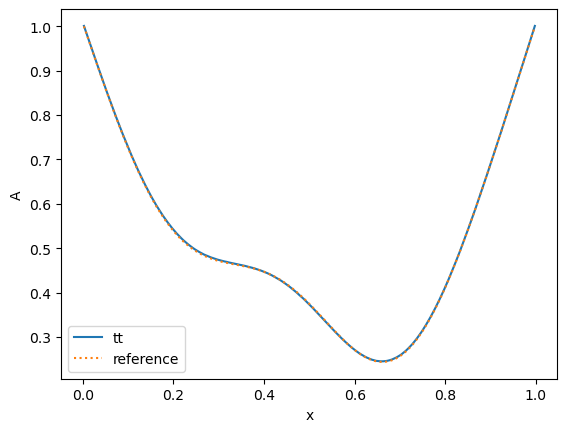

In [4]:
# eval TT-approx of coeff
y = rng.integers(0, Ny, n_a_param)
C_eval = np.empty(Nx)
for i in range(Nx):
  C_eval[i] = C_a[np.concatenate([[i, 0], y])].ravel()[0]

X = np.hstack([np.arange(Nx).reshape((-1,1)), np.zeros((Nx,1)), np.tile(y, [Nx,1])])
C_true = cfun(X)

fig, ax = plt.subplots()

x = (np.arange(0, Nx) + .5) / Nx
ax.plot(x, C_eval, label='tt')
ax.plot(x, C_true, ls='dotted', label="reference")
ax.set_xlabel('x')
ax.set_ylabel('A')
ax.legend()

In [5]:
# tensor for convection
C_v = TreeBasedTensor.ones(tree, (1,) + param_shape)
C_v.cores[C_v.tree.dim2leaf(1)] = np.linspace(v_min,v_max, Ny).reshape(-1,1)

# helper tensor that is constant 1
C_const = TreeBasedTensor.ones(tree, (1,) + param_shape)
C_const2 = TreeBasedTensor.ones(tree, (1,) + param_shape)

print(C_v[0, :,1,0,0,0,0].ravel())

[-10.          -7.77777778  -5.55555556  -3.33333333  -1.11111111
   1.11111111   3.33333333   5.55555556   7.77777778  10.        ]


### ALS-cross test

In [6]:

from tree_als_cross import TreeALSCross

test = TreeALSCross(
  [C_a, C_v, C_const],
  [C_const2],
  PDE_fun,
  )

test.run(verbose=True)

Init finished
= swp=0 core 0, max_dx=1.00e+00


TypeError: object of type 'TreeNode' has no len()

### Test ALS-cross accuracy

Compare ALS cross approximation vs PDE solution for a random sample

In [ ]:
N_MC = 500
err = 0

for n in range(N_MC):
  # get random parameter
  y = rng.integers(0, Ny, n_param)
  X = np.hstack([np.arange(Nx).reshape((-1,1)), np.tile(y, [Nx,1])])

  C_a_true = cfun(X) # compute true coeff
  v_true = np.linspace(v_min,v_max,Ny)[y[0]]

  U = PDE_fun.solve([[C_a_true.reshape(1,-1,1), v_true * np.ones((1,1,1)), np.zeros((1,1,1))], [np.zeros((1,1,1))]]) # solve PDE
  U = np.ravel(U)

  # eval ALS-cross
  U_eval = np.empty(u.n[0])
  for i in range(u.n[0]):
    U_eval[i] = u[np.concatenate(([i], y))]

  err += np.sum(np.square(U - U_eval))

err = np.sqrt(err / N_MC)

print(f'RMS l2 err = {err:.2e}')


In [ ]:
# get random parameter
y = rng.integers(0, Ny, n_param)
X = np.hstack([np.arange(Nx).reshape((-1,1)), np.tile(y, [Nx,1])])

C_a_true = cfun(X) # compute true coeff
v_true = np.linspace(v_min,v_max,Ny)[y[0]]

U = PDE_fun.solve([[C_a_true.reshape(1,-1,1), v_true * np.ones((1,1,1)), np.zeros((1,1,1))], [np.zeros((1,1,1))]]) # solve PDE
U = np.ravel(U)

# eval ALS-cross
U_eval = np.empty(u.n[0])
for i in range(u.n[0]):
  U_eval[i] = u[np.concatenate(([i], y))]

fig, ax = plt.subplots()

x = np.arange(0, Nx+1) / Nx
ax.plot(x, U_eval, label='ALS-cross')
ax.plot(x, U, ls='dashed', label='reference')
ax.set_xlabel('x')
ax.set_ylabel('u')
ax.legend()